In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import warnings
import enclus
warnings.filterwarnings('ignore')

sc.set_figure_params(dpi=300,fontsize=10,dpi_save=300,facecolor='white',format='pdf')
sc.settings.figdir = './Result/hypothalamic/'

## ENVI

In [1]:
import warnings
warnings.filterwarnings('ignore')
import scipy.sparse as sp
import scenvi
import scanpy as sc

In [2]:
st_data = sc.read('./datasets/ProcessedMERFISH_hypothalamic_st_data.h5ad')
sc_data = sc.read('./datasets/ProcessedMERFISH_hypothalamic_sc_data.h5ad')
if isinstance(sc_data.X, sp.csr_matrix):
    sc_data.X = sc_data.X.toarray()
print(sc_data,st_data)

AnnData object with n_obs × n_vars = 30370 × 27998
    obs: 'cell_type', 'domain_id', 'source'
    var: 'Gene'
    uns: 'log1p' AnnData object with n_obs × n_vars = 64373 × 155
    obs: 'cell_type', 'domain_id', 'source'
    uns: 'log1p'
    obsm: 'spatial'


In [3]:
envi_model = scenvi.ENVI(spatial_data = st_data, sc_data = sc_data,
                    num_layers=3,
                    num_neurons=1024,
                    latent_dim=512,
                    k_nearest=8,
                    num_cov_genes=64,
                    cov_genes=[],
                    num_HVG=2048,
                    spatial_dist="pois",
                    sc_dist="nb",
                    spatial_coeff=1,     
                    sc_coeff=1,         
                    kl_coeff=0.3, 
                    )

envi_model.train(training_steps=6000,
    batch_size=4096,
    verbose=16,
    init_lr=0.0001,
    decay_steps=4000)

envi_model.impute_genes()

st_data.obsm['envi_latent'] = envi_model.spatial_data.obsm['envi_latent']
st_data.obsm['imputation'] = envi_model.spatial_data.obsm['imputation']
sc_data.obsm['envi_latent'] = envi_model.sc_data.obsm['envi_latent']

DEBUG
sc_genes_keep shape: (2189,)
sc_data shape and st_data shape: (30370, 2189) (64373, 154)
Computing Niche Covariance Matrices
(64373, 64, 64)
Initializing CVAE
Finished Initializing ENVI


 spatial: -2.539e-01 sc: -5.527e-02 cov: -3.925e-04 kl: 5.115e-01: 100%|██████████| 6000/6000 [1:58:32<00:00,  1.19s/it]


Finished imputing missing gene for spatial data! See 'imputation' in obsm of ENVI.spatial_data


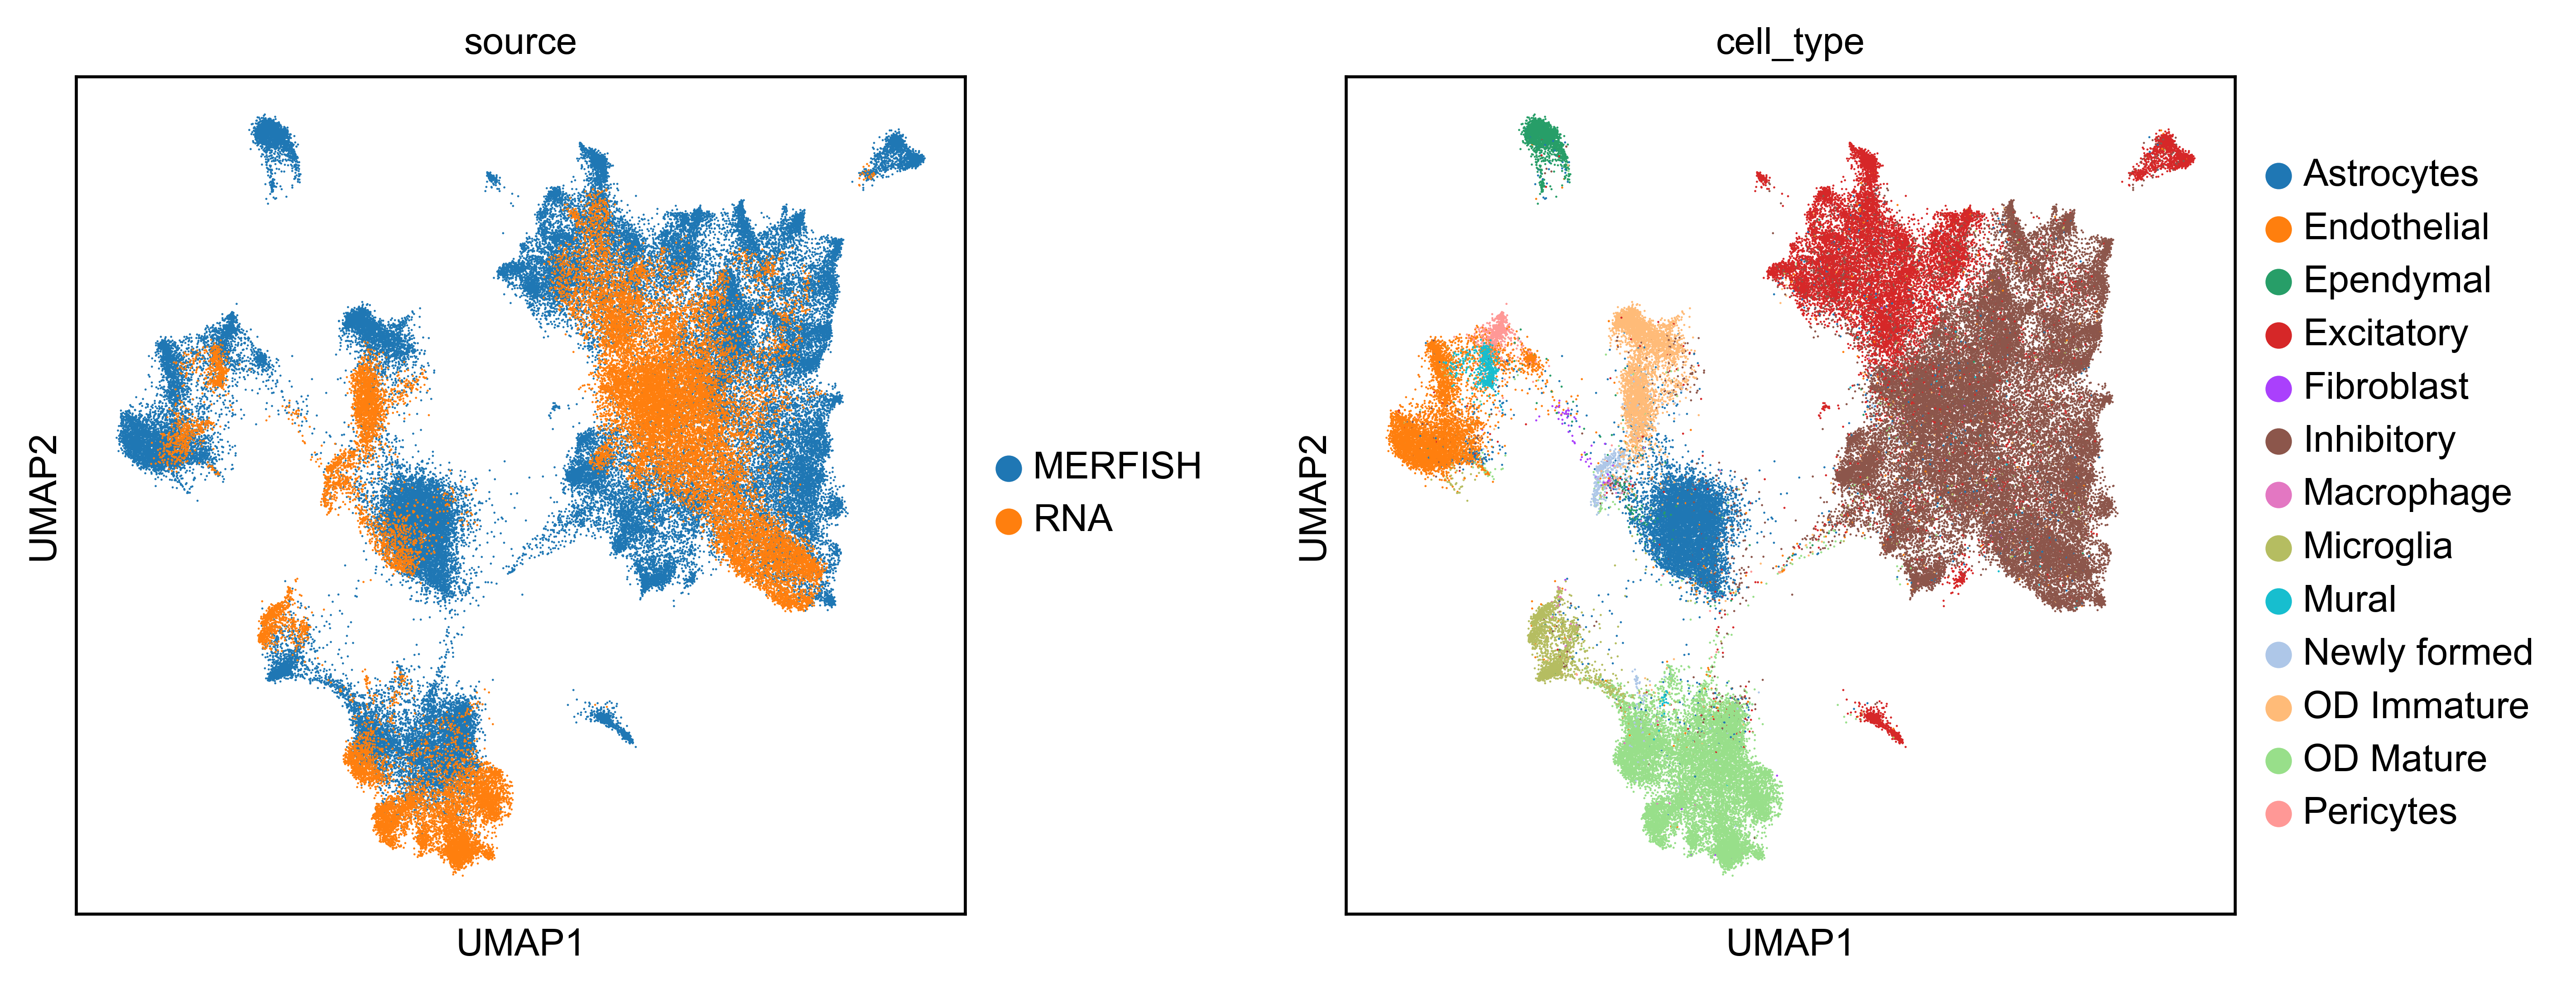

In [79]:
import anndata as ad
sc.settings.figdir = './Result/hypothalamic/'
use_rep = 'envi_latent'
adata = ad.concat([st_data,sc_data], join='inner', merge='same')
sc.tl.pca(adata)
sc.pp.neighbors(adata, use_rep=use_rep, n_neighbors=30)
sc.tl.umap(adata,min_dist=0.1, n_components=2)
sc.pl.umap(adata, color=['source','cell_type'],save='envi-integrate.pdf',wspace=0.3,legend_fontsize=10)

In [78]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, f1_score
import enclus.metrics
adata1 = adata[adata.obs['domain_id']==0]
adata2 = adata[adata.obs['domain_id']==1]
y_test = enclus.metrics.label_transfer(adata2, adata1, label='cell_type', rep='X_umap')

f1 = f1_score(adata1.obs['cell_type'], y_test, average='weighted')
ARI = adjusted_rand_score(adata1.obs['cell_type'], y_test)
NMI = normalized_mutual_info_score(adata1.obs['cell_type'], y_test)
print('F1:', f1)
print('ARI:', ARI)
print('NMI:', NMI)
print('total score:',f1+ARI+NMI)
print('Batch Entropy:', enclus.metrics.batch_entropy_mixing_score(adata.obsm['X_umap'], adata.obs['domain_id']))
print('Silhouette:', enclus.metrics.silhouette(adata.obsm['X_umap'], adata.obs['cell_type']))

F1: 0.6983673279169839
ARI: 0.4894414463648024
NMI: 0.5427109370214813
total score: 1.7305197113032675
Batch Entropy: 0.32932896975983644
Silhouette: 0.556878


## SpateCV-attention

In [ ]:
import scanpy as sc

import warnings
warnings.filterwarnings('ignore')
import scipy.sparse as sp
import enclus

sc.set_figure_params(dpi=300,fontsize=10,dpi_save=300,facecolor='white',format='pdf')

In [ ]:
st_data = sc.read('./datasets/ProcessedMERFISH_hypothalamic_st_data.h5ad')
sc_data = sc.read('./datasets/ProcessedMERFISH_hypothalamic_sc_data.h5ad')
if isinstance(sc_data.X, sp.csr_matrix):
    sc_data.X = sc_data.X.toarray()
print(sc_data,st_data)

AnnData object with n_obs × n_vars = 30370 × 27998
    obs: 'cell_type', 'domain_id', 'source'
    var: 'Gene'
    uns: 'log1p' AnnData object with n_obs × n_vars = 64373 × 155
    obs: 'cell_type', 'domain_id', 'source'
    uns: 'log1p'
    obsm: 'spatial'


In [ ]:
enclus_model = enclus.ENCLUS(spatial_data = st_data, sc_data = sc_data,
                    num_layers=3,
                    num_neurons=1024,
                    latent_dim=512,
                    k_nearest=8,
                    num_cov_genes=64,
                    num_HVG=2048,
                    spatial_dist="pois",
                    sc_dist="nb",
                    spatial_coeff=1,  
                    sc_coeff=1,   
                    kl_coeff=0.3,
                    n_clusters=6,
                    tau=0.1,
                    gamma=0.1,
                    adaptive_weights=False,
                    early_stopping=False,
                    patience=20
                    )

enclus_model.train(training_steps=6000,
    batch_size=4096,
    verbose=100,
    init_lr=0.0001,
    decay_steps=4000)

enclus_model.impute_genes()

st_data.obsm['enclus_latent'] = enclus_model.spatial_data.obsm['enclus_latent']
st_data.obsm['imputation'] = enclus_model.spatial_data.obsm['imputation']
sc_data.obsm['enclus_latent'] = enclus_model.sc_data.obsm['enclus_latent']

sc_data shape and st_data shape: (30370, 2189) (64373, 154)
Initializing CVAE
Finished Initializing ENCLUS
Initializing cluster centers...


100%|██████████| 6000/6000 [3:07:12<00:00,  1.87s/it]  


Finished imputing missing gene for spatial data! See 'imputation' in obsm of ENCLUS.spatial_data


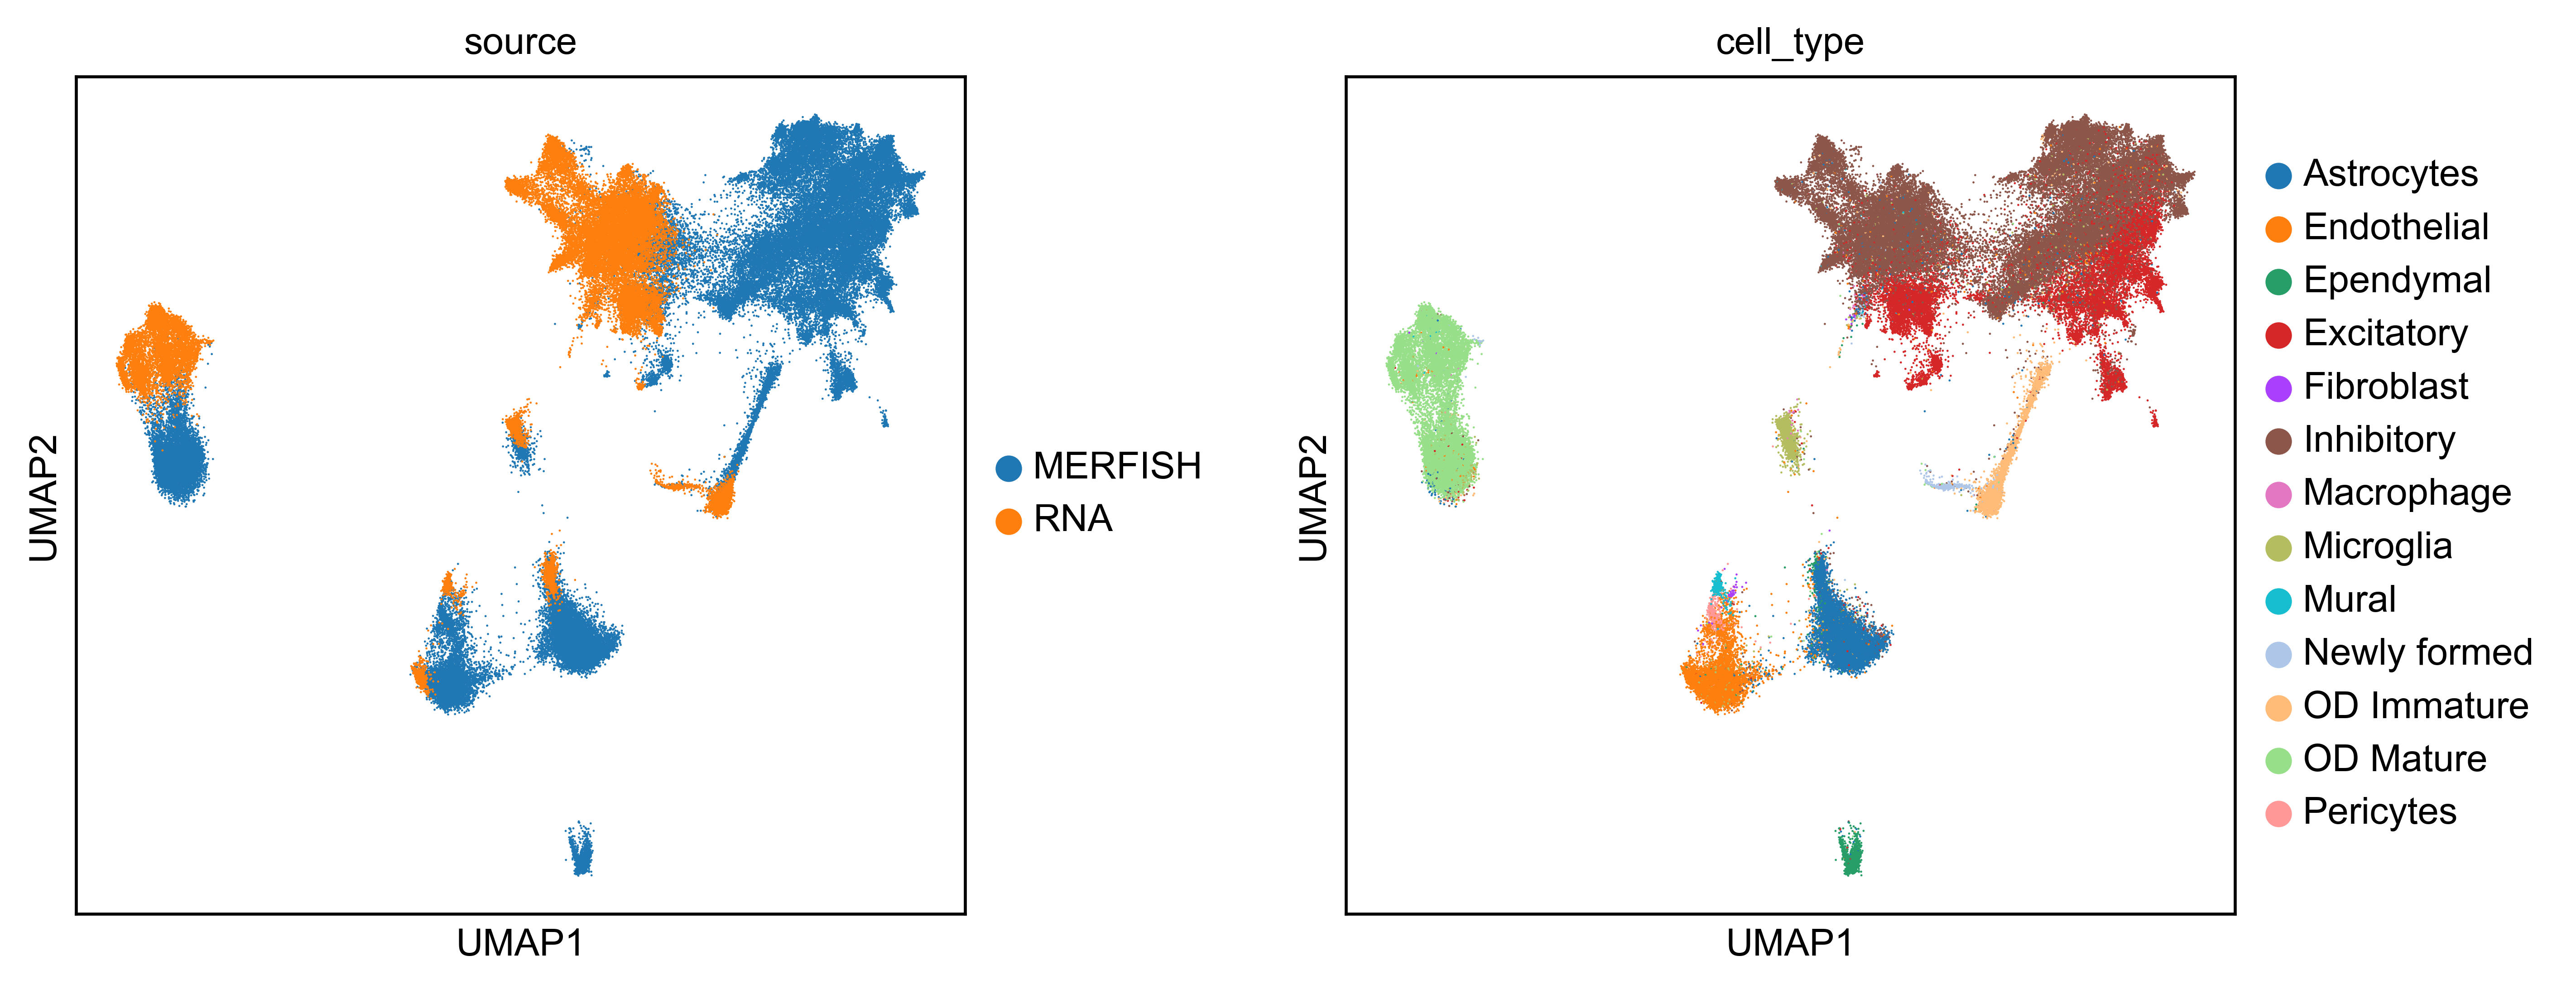

In [ ]:
import anndata as ad
# sc.settings.figdir = './Result/hypothalamic/'
use_rep = 'enclus_latent'
adata = ad.concat([st_data,sc_data], join='inner', merge='same')
sc.tl.pca(adata)
sc.pp.neighbors(adata, use_rep=use_rep, n_neighbors=30)
sc.tl.umap(adata,min_dist=0.1, n_components=2)
sc.pl.umap(adata, color=['source','cell_type'],save='enclus-attention.pdf',wspace=0.3,legend_fontsize=10)

In [ ]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, f1_score
import enclus.metrics
adata1 = adata[adata.obs['domain_id']==0]
adata2 = adata[adata.obs['domain_id']==1]
y_test = enclus.metrics.label_transfer(adata2, adata1, label='cell_type', rep='X_umap') #n_neighbors=30,n=6.weighted

f1 = f1_score(adata1.obs['cell_type'], y_test, average='weighted')
ARI = adjusted_rand_score(adata1.obs['cell_type'], y_test)
NMI = normalized_mutual_info_score(adata1.obs['cell_type'], y_test)
print('F1:', f1)
print('ARI:', ARI)
print('NMI:', NMI)
print('total score:',f1+ARI+NMI)
print('Batch Entropy:', enclus.metrics.batch_entropy_mixing_score(adata.obsm['X_umap'], adata.obs['domain_id']))
print('Silhouette:', enclus.metrics.silhouette(adata.obsm['X_umap'], adata.obs['cell_type']))

F1: 0.6882205254997633
ARI: 0.6120964721454177
NMI: 0.6706237599410995
total score: 1.9709407575862805
Batch Entropy: 0.079765736196465
Silhouette: 0.61093706


## SpateCV-cluster

In [ ]:
import scanpy as sc

import warnings
warnings.filterwarnings('ignore')
import scipy.sparse as sp
import enclus

sc.set_figure_params(dpi=300,fontsize=10,dpi_save=300,facecolor='white',format='pdf')

In [ ]:
st_data = sc.read('./datasets/ProcessedMERFISH_hypothalamic_st_data.h5ad')
sc_data = sc.read('./datasets/ProcessedMERFISH_hypothalamic_sc_data.h5ad')
if isinstance(sc_data.X, sp.csr_matrix):
    sc_data.X = sc_data.X.toarray()
print(sc_data,st_data)

AnnData object with n_obs × n_vars = 30370 × 27998
    obs: 'cell_type', 'domain_id', 'source'
    var: 'Gene'
    uns: 'log1p' AnnData object with n_obs × n_vars = 64373 × 155
    obs: 'cell_type', 'domain_id', 'source'
    uns: 'log1p'
    obsm: 'spatial'


In [ ]:
enclus_model = enclus.ENCLUS(spatial_data = st_data, sc_data = sc_data,
                    num_layers=3,
                    num_neurons=1024,
                    latent_dim=512,
                    k_nearest=8,
                    num_cov_genes=64,
                    cov_genes=[],
                    num_HVG=2048,
                    # sc_genes=add_genes,
                    spatial_dist="pois",
                    sc_dist="nb",
                    spatial_coeff=1,  
                    sc_coeff=1,   
                    kl_coeff=0.3, #0.03
                    # n_clusters=6,
                    # tau=0.1, #0.2
                    # gamma=0.1,
                    adaptive_weights=False,
                    early_stopping=False,
                    patience=20,
                    num_heads=8,
                    head_dim=64,
                    )

enclus_model.train(training_steps=6000,
    batch_size=4096,
    verbose=16,
    init_lr=0.0001,
    decay_steps=4000)

enclus_model.impute_genes()

st_data.obsm['enclus_latent'] = enclus_model.spatial_data.obsm['enclus_latent']
st_data.obsm['imputation'] = enclus_model.spatial_data.obsm['imputation']
sc_data.obsm['enclus_latent'] = enclus_model.sc_data.obsm['enclus_latent']

sc_data shape and st_data shape: (30370, 2189) (64373, 154)
Initializing CVAE
Finished Initializing ENCLUS


 | spatial_w: 1.00 sc_w: 1.00 cov_w: 1.00 kl_w: 1.00: 100%|██████████| 6000/6000 [4:46:36<00:00,  2.87s/it]  


Finished imputing missing gene for spatial data! See 'imputation' in obsm of ENCLUS.spatial_data


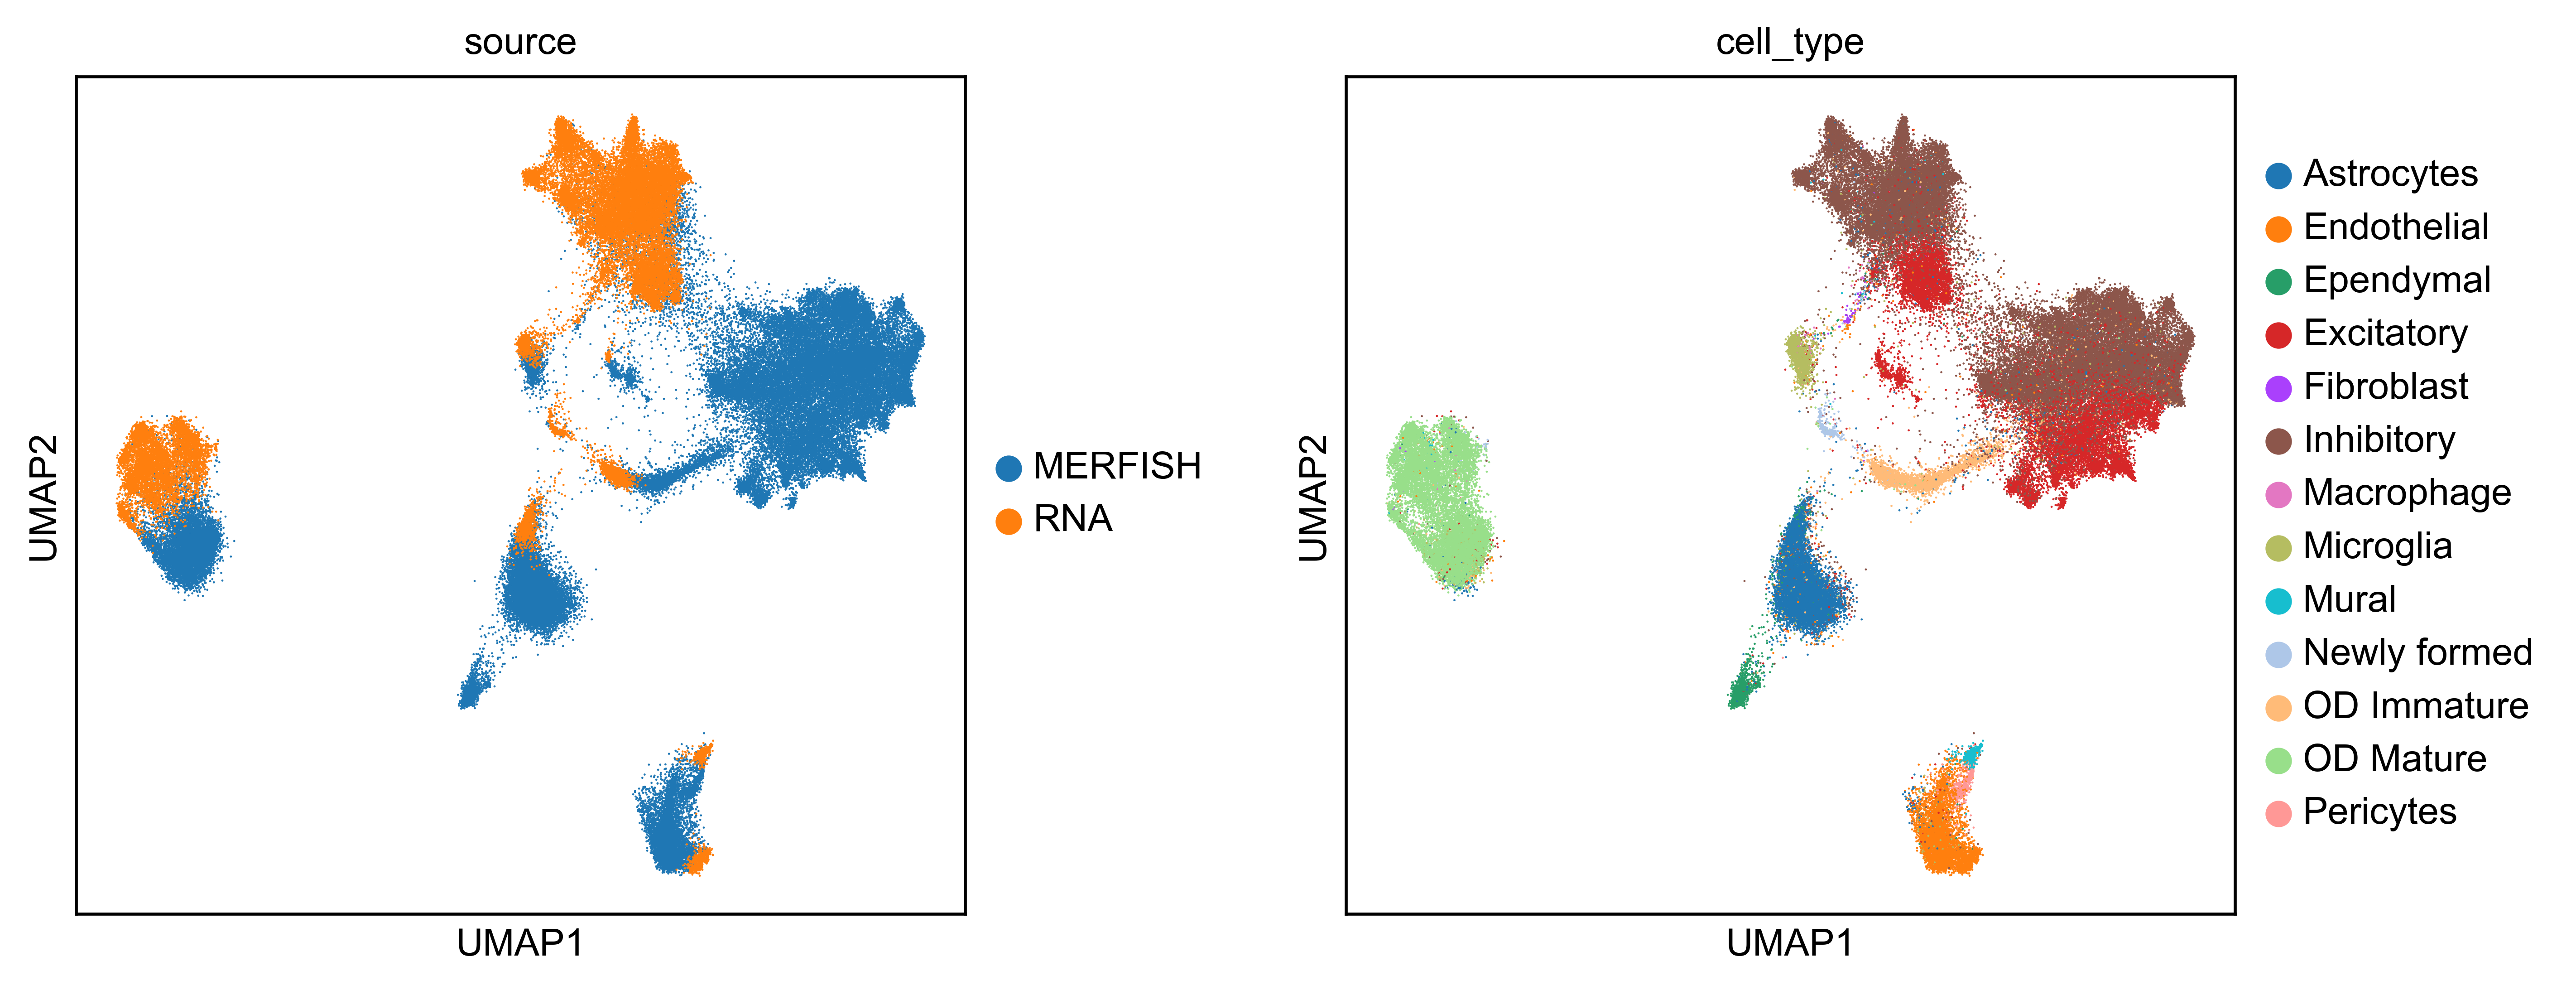

In [ ]:
import anndata as ad
# sc.settings.figdir = './Result/hypothalamic/'
use_rep = 'enclus_latent'
adata = ad.concat([st_data,sc_data], join='inner', merge='same')
sc.tl.pca(adata)
sc.pp.neighbors(adata, use_rep=use_rep, n_neighbors=30)
sc.tl.umap(adata,min_dist=0.1, n_components=2)
sc.pl.umap(adata, color=['source','cell_type'],save='enclus-cluster.pdf',wspace=0.3,legend_fontsize=10)

In [ ]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, f1_score
import enclus.metrics
adata1 = adata[adata.obs['domain_id']==0]
adata2 = adata[adata.obs['domain_id']==1]
y_test = enclus.metrics.label_transfer(adata2, adata1, label='cell_type', rep='X_umap') 

f1 = f1_score(adata1.obs['cell_type'], y_test, average='weighted')
ARI = adjusted_rand_score(adata1.obs['cell_type'], y_test)
NMI = normalized_mutual_info_score(adata1.obs['cell_type'], y_test)
print('F1:', f1)
print('ARI:', ARI)
print('NMI:', NMI)
print('total score:',f1+ARI+NMI)
print('Batch Entropy:', enclus.metrics.batch_entropy_mixing_score(adata.obsm['X_umap'], adata.obs['domain_id']))
print('Silhouette:', enclus.metrics.silhouette(adata.obsm['X_umap'], adata.obs['cell_type']))

F1: 0.6769451912099578
ARI: 0.592820885484314
NMI: 0.6542111298883194
total score: 1.9239772065825913
Batch Entropy: 0.08370712055284406
Silhouette: 0.5758548
